In [2]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Download dataset
path = kagglehub.dataset_download("vivek468/superstore-dataset-final")
print("Path to dataset files:", path)

# Find the CSV file in the downloaded path
files = os.listdir(path)
print("Files found:", files)

# Load the CSV
csv_file = [f for f in files if f.endswith('.csv')][0]
df = pd.read_csv(os.path.join(path, csv_file), encoding='latin-1')

# Display first 5 rows
print(f"\nDataset loaded successfully! Shape: {df.shape}")
df.head()

100%|██████████| 550k/550k [00:01<00:00, 473kB/s]

Extracting files...
Path to dataset files: C:\Users\Admin\.cache\kagglehub\datasets\vivek468\superstore-dataset-final\versions\1
Files found: ['Sample - Superstore.csv']

Dataset loaded successfully! Shape: (9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
# Create screenshots folder if it doesn't exist
os.makedirs('screenshots', exist_ok=True)

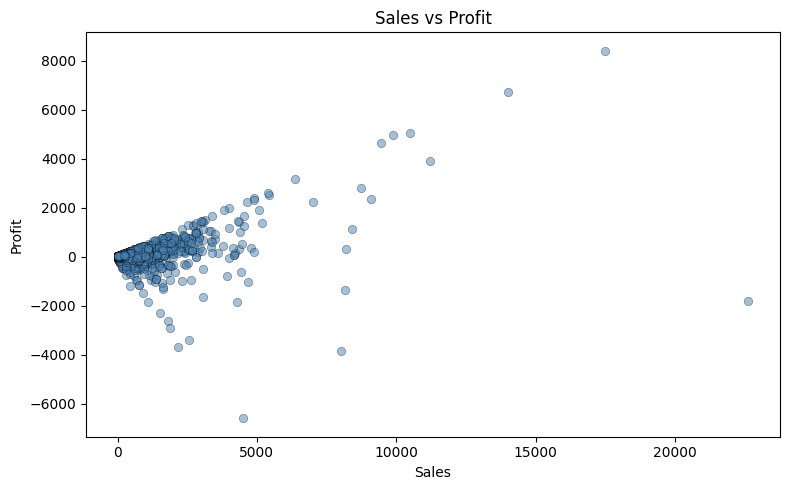

Insight: There is a general positive relationship between Sales and Profit, though high discounts cause some high-sales items to result in losses.


In [5]:
# --- 1. Scatter Plot: Sales vs Profit ---
plt.figure(figsize=(8, 5))
plt.scatter(df['Sales'], df['Profit'], alpha=0.5, color='steelblue', edgecolors='black', linewidths=0.4)
plt.title('Sales vs Profit')
plt.xlabel('Sales')
plt.ylabel('Profit')
plt.tight_layout()
plt.savefig('screenshots/scatter_sales_profit.png')
plt.show()
print("Insight: There is a general positive relationship between Sales and Profit, though high discounts cause some high-sales items to result in losses.")

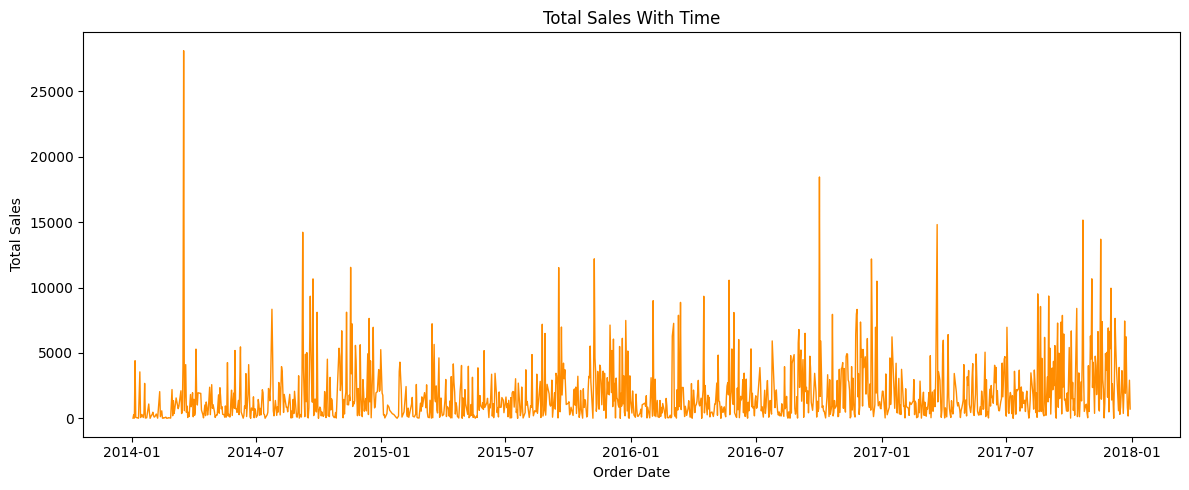

Insight: Sales show an upward trend over time with noticeable spikes, likely corresponding to seasonal demand or promotional periods.


In [6]:
#Line Plot: Total Sales Over Time ---
df['Order Date'] = pd.to_datetime(df['Order Date'])
df_time = df.groupby('Order Date')['Sales'].sum().reset_index()

plt.figure(figsize=(12, 5))
plt.plot(df_time['Order Date'], df_time['Sales'], color='darkorange', linewidth=1)
plt.title('Total Sales With Time')
plt.xlabel('Order Date')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.savefig('screenshots/line_sales_over_time.png')
plt.show()
print("Insight: Sales show an upward trend over time with noticeable spikes, likely corresponding to seasonal demand or promotional periods.")

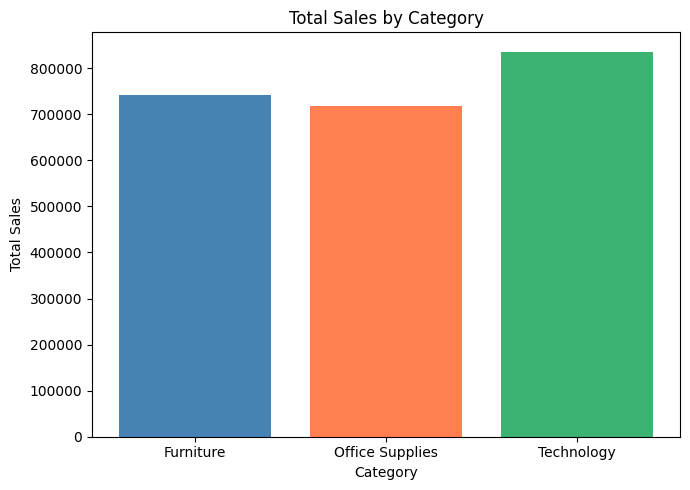

Insight: Technology has the highest total sales among all categories, followed by Furniture and Office Supplies.


In [7]:
#Total Sales by Category
category_sales = df.groupby('Category')['Sales'].sum().reset_index()

plt.figure(figsize=(7, 5))
plt.bar(category_sales['Category'], category_sales['Sales'], color=['steelblue', 'coral', 'mediumseagreen'])
plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.savefig('screenshots/bar_sales_by_category.png')
plt.show()
print("Insight: Technology has the highest total sales among all categories, followed by Furniture and Office Supplies.")

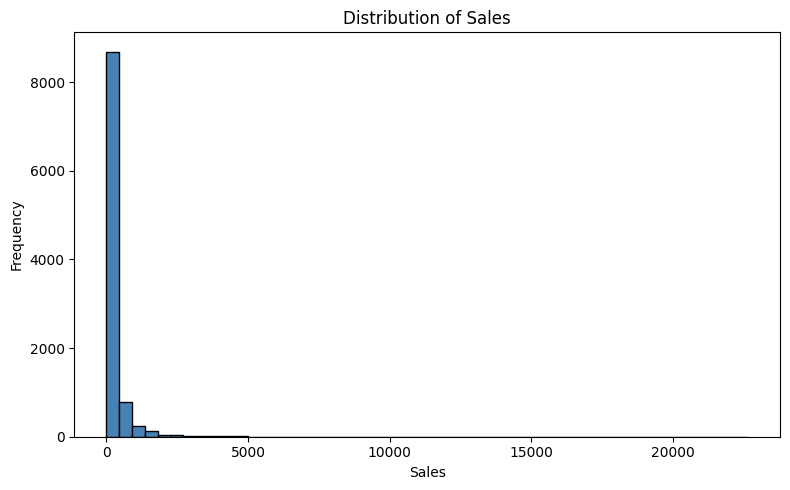

Insight: The distribution of Sales is heavily right-skewed, meaning most transactions are low-value with a few very high-value outliers.


In [8]:
# Histogram: Distribution of Sales ---
plt.figure(figsize=(8, 5))
plt.hist(df['Sales'], bins=50, color='steelblue', edgecolor='black')
plt.title('Distribution of Sales')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('screenshots/histogram_sales.png')
plt.show()
print("Insight: The distribution of Sales is heavily right-skewed, meaning most transactions are low-value with a few very high-value outliers.")

In [9]:
from google.colab import drive
drive.mount('/content/drive')

ModuleNotFoundError: No module named 'google.colab'

<Figure size 800x500 with 0 Axes>

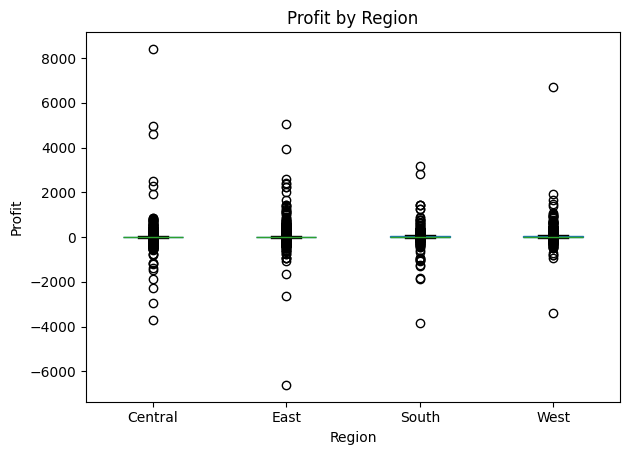

Insight: The West region shows the highest median profit. All regions contain outliers on both ends, indicating high variability in profit.


In [ ]:
#Box Plot: Profit by Region
plt.figure(figsize=(8, 5))
df.boxplot(column='Profit', by='Region', grid=False, patch_artist=True)
plt.title('Profit by Region')
plt.suptitle('')
plt.xlabel('Region')
plt.ylabel('Profit')
plt.tight_layout()
plt.savefig('screenshots/boxplot_profit_by_region.png')
plt.show()
print("Insight: The West region shows the highest median profit. All regions contain outliers on both ends, indicating high variability in profit.")

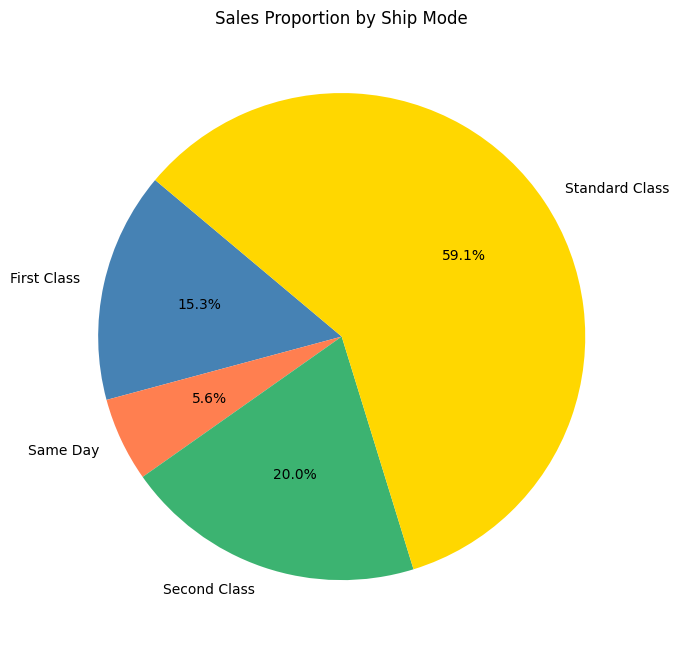

Insight: Standard Class accounts for the largest share of sales by ship mode, suggesting it is the most preferred shipping option.


In [ ]:
#Pie Chart: Sales Proportion by Ship Mode
shipmode_sales = df.groupby('Ship Mode')['Sales'].sum()

plt.figure(figsize=(7, 7))
plt.pie(shipmode_sales, labels=shipmode_sales.index, autopct='%1.1f%%',
        colors=['steelblue', 'coral', 'mediumseagreen', 'gold'], startangle=140)
plt.title('Sales Proportion by Ship Mode')
plt.tight_layout()
plt.savefig('screenshots/pie_shipmode_sales.png')
plt.show()
print("Insight: Standard Class accounts for the largest share of sales by ship mode, suggesting it is the most preferred shipping option.")

In [ ]:
#Handling Missing Values
print("=== Missing Values BEFORE Handling ===")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

=== Missing Values BEFORE Handling ===
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Total missing values: 0


In [ ]:
#Fill missing numeric values with column mean
numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

#Fill missing categorical values with mode
categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("=== Missing Values AFTER Handling ===")
print(df.isnull().sum())
print("\nAll missing values have been handled.")

=== Missing Values AFTER Handling ===
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

All missing values have been handled.


In [ ]:
#Outlier Detection and Removal (IQR Method)
print("=== Outlier Detection on 'Sales' Column (IQR Method) ===\n")

Q1 = df['Sales'].quantile(0.25)
Q3 = df['Sales'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1           : {Q1:.2f}")
print(f"Q3           : {Q3:.2f}")
print(f"IQR          : {IQR:.2f}")
print(f"Lower Bound  : {lower_bound:.2f}")
print(f"Upper Bound  : {upper_bound:.2f}")

outliers = df[(df['Sales'] < lower_bound) | (df['Sales'] > upper_bound)]
print(f"\nNumber of outliers detected: {len(outliers)}")
print("\nSample of outliers:")
print(outliers[['Sales', 'Profit', 'Category']].head(10))

=== Outlier Detection on 'Sales' Column (IQR Method) ===

Q1           : 17.28
Q3           : 209.94
IQR          : 192.66
Lower Bound  : -271.71
Upper Bound  : 498.93

Number of outliers detected: 1167

Sample of outliers:
        Sales     Profit         Category
1    731.9400   219.5820        Furniture
3    957.5775  -383.0310        Furniture
7    907.1520    90.7152       Technology
10  1706.1840    85.3092        Furniture
11   911.4240    68.3568       Technology
16   665.8800    13.3176  Office Supplies
24  1044.6300   240.2649        Furniture
27  3083.4300 -1665.0522        Furniture
35  1097.5440   123.4737       Technology
38   532.3992   -46.9764        Furniture


In [ ]:
#Dataset before and after outlier removal
print(f"\nDataset shape BEFORE outlier removal: {df.shape}")
df_no_outliers = df[(df['Sales'] >= lower_bound) & (df['Sales'] <= upper_bound)]
print(f"Dataset shape AFTER outlier removal : {df_no_outliers.shape}")


Dataset shape BEFORE outlier removal: (9994, 21)
Dataset shape AFTER outlier removal : (8827, 21)


In [ ]:
#Data Reduction
print("=== Data Reduction ===\n")
print(f"Original dataset shape: {df.shape}")

# Sampling - 50% of the data
df_sampled = df.sample(frac=0.5, random_state=42)
print(f"After 50% random sampling: {df_sampled.shape}")

# Dimension elimination - drop less relevant columns
cols_to_drop = ['Row ID', 'Order ID', 'Customer ID', 'Customer Name',
                'Country', 'Postal Code', 'Product ID', 'Product Name']
df_reduced = df.drop(columns=cols_to_drop)

print(f"\nNumber of columns BEFORE dimension elimination: {df.shape[1]}")
print(f"Number of columns AFTER dimension elimination : {df_reduced.shape[1]}")
print(f"\nRemaining columns: {list(df_reduced.columns)}")

=== Data Reduction ===

Original dataset shape: (9994, 21)
After 50% random sampling: (4997, 21)

Number of columns BEFORE dimension elimination: 21
Number of columns AFTER dimension elimination : 13

Remaining columns: ['Order Date', 'Ship Date', 'Ship Mode', 'Segment', 'City', 'State', 'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount', 'Profit']


In [ ]:
#Data Scaling and Discretization
from sklearn.preprocessing import MinMaxScaler

print("=== Numeric Columns BEFORE Scaling ===")
print(df[['Sales', 'Profit', 'Quantity', 'Discount']].describe())

#Min-Max Scaling
scaler = MinMaxScaler()
df_scaled = df.copy()
df_scaled[['Sales', 'Profit', 'Quantity', 'Discount']] = scaler.fit_transform(
    df[['Sales', 'Profit', 'Quantity', 'Discount']]
)

print("\n=== Numeric Columns AFTER Min-Max Scaling ===")
print(df_scaled[['Sales', 'Profit', 'Quantity', 'Discount']].describe())

In [ ]:
#Discretization - bin Sales into meaningful categories
df['Sales_Category'] = pd.cut(
    df['Sales'],
    bins=[0, 100, 500, 1000, 5000, df['Sales'].max()],
    labels=['Very Low', 'Low', 'Medium', 'High', 'Very High']
)

print("\n=== Sales Discretization (Before -> Continuous, After -> Categories) ===")
print(df['Sales_Category'].value_counts())


=== Sales Discretization (Before -> Continuous, After -> Categories) ===
Sales_Category
Very Low     6229
Low          2603
Medium        694
High          449
Very High      19
Name: count, dtype: int64


In [ ]:
#STATISTICAL ANALYSIS
#General Overview
print("=== Dataset Info ===\n")
df.info()

=== Dataset Info ===

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          9994 non-null   int64         
 1   Order ID        9994 non-null   object        
 2   Order Date      9994 non-null   datetime64[ns]
 3   Ship Date       9994 non-null   object        
 4   Ship Mode       9994 non-null   object        
 5   Customer ID     9994 non-null   object        
 6   Customer Name   9994 non-null   object        
 7   Segment         9994 non-null   object        
 8   Country         9994 non-null   object        
 9   City            9994 non-null   object        
 10  State           9994 non-null   object        
 11  Postal Code     9994 non-null   int64         
 12  Region          9994 non-null   object        
 13  Product ID      9994 non-null   object        
 14  Category        9994 non-null   ob

In [ ]:
print("\n=== Dataset Description ===\n")
df.describe()


=== Dataset Description ===



,Row ID,Order Date,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2016-04-30 00:07:12.259355648,55190.379428,229.858001,3.789574,0.156203,28.656896
min,1.000000,2014-01-03 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,2015-05-23 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,2016-06-26 00:00:00,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,2017-05-14 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,2017-12-30 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000
std,2885.163629,NaN,32063.693350,623.245101,2.225110,0.206452,234.260108


In [ ]:
#Central Tendency Measures
print("=== Central Tendency Measures ===\n")

for col in ['Sales', 'Profit', 'Quantity', 'Discount']:
    print(f"--- {col} ---")
    print(f"  Minimum : {df[col].min():.4f}")
    print(f"  Maximum : {df[col].max():.4f}")
    print(f"  Mean    : {df[col].mean():.4f}")
    print(f"  Median  : {df[col].median():.4f}")
    print(f"  Mode    : {df[col].mode()[0]:.4f}")
    print()

=== Central Tendency Measures ===

--- Sales ---
  Minimum : 0.4440
  Maximum : 22638.4800
  Mean    : 229.8580
  Median  : 54.4900
  Mode    : 12.9600

--- Profit ---
  Minimum : -6599.9780
  Maximum : 8399.9760
  Mean    : 28.6569
  Median  : 8.6665
  Mode    : 0.0000

--- Quantity ---
  Minimum : 1.0000
  Maximum : 14.0000
  Mean    : 3.7896
  Median  : 3.0000
  Mode    : 3.0000

--- Discount ---
  Minimum : 0.0000
  Maximum : 0.8000
  Mean    : 0.1562
  Median  : 0.2000
  Mode    : 0.0000



In [ ]:
#Dispersion Measures
print("=== Dispersion Measures ===\n")
for col in ['Sales', 'Profit', 'Quantity', 'Discount']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    print(f"--- {col} ---")
    print(f"  Range               : {df[col].max() - df[col].min():.4f}")
    print(f"  Q1 (25th percentile): {Q1:.4f}")
    print(f"  Q3 (75th percentile): {Q3:.4f}")
    print(f"  IQR                 : {IQR:.4f}")
    print(f"  Variance            : {df[col].var():.4f}")
    print(f"  Standard Deviation  : {df[col].std():.4f}")
    print()

=== Dispersion Measures ===

--- Sales ---
  Range               : 22638.0360
  Q1 (25th percentile): 17.2800
  Q3 (75th percentile): 209.9400
  IQR                 : 192.6600
  Variance            : 388434.4553
  Standard Deviation  : 623.2451

--- Profit ---
  Range               : 14999.9540
  Q1 (25th percentile): 1.7288
  Q3 (75th percentile): 29.3640
  IQR                 : 27.6352
  Variance            : 54877.7981
  Standard Deviation  : 234.2601

--- Quantity ---
  Range               : 13.0000
  Q1 (25th percentile): 2.0000
  Q3 (75th percentile): 5.0000
  IQR                 : 3.0000
  Variance            : 4.9511
  Standard Deviation  : 2.2251

--- Discount ---
  Range               : 0.8000
  Q1 (25th percentile): 0.0000
  Q3 (75th percentile): 0.2000
  IQR                 : 0.2000
  Variance            : 0.0426
  Standard Deviation  : 0.2065



=== Correlation Matrix ===

             Sales    Profit  Quantity  Discount
Sales     1.000000  0.479064  0.200795 -0.028190
Profit    0.479064  1.000000  0.066253 -0.219487
Quantity  0.200795  0.066253  1.000000  0.008623
Discount -0.028190 -0.219487  0.008623  1.000000


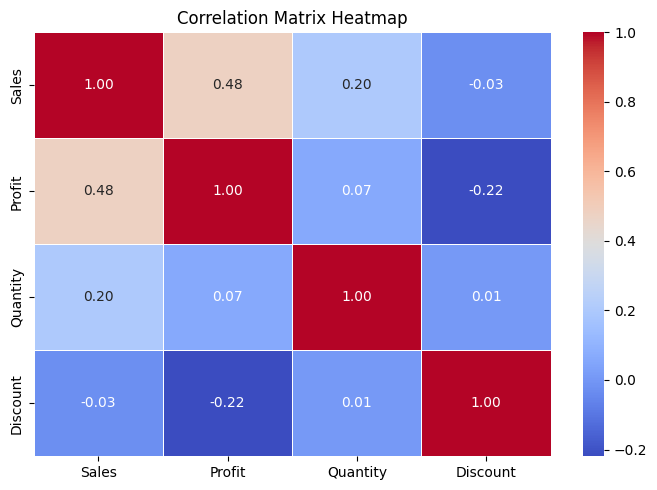


Insight: Discount has a negative correlation with Profit, confirming that higher discounts lead to lower profitability.


In [ ]:
#Correlation Analysis
print("=== Correlation Matrix ===\n")
numeric_df = df[['Sales', 'Profit', 'Quantity', 'Discount']]
corr_matrix = numeric_df.corr()
print(corr_matrix)

#Heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.tight_layout()
plt.savefig('screenshots/correlation_heatmap.png')
plt.show()
print("\nInsight: Discount has a negative correlation with Profit, confirming that higher discounts lead to lower profitability.")